
Accuracy:
98.27 %

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      4710
           1       0.98      0.99      0.98      4270

    accuracy                           0.98      8980
   macro avg       0.98      0.98      0.98      8980
weighted avg       0.98      0.98      0.98      8980



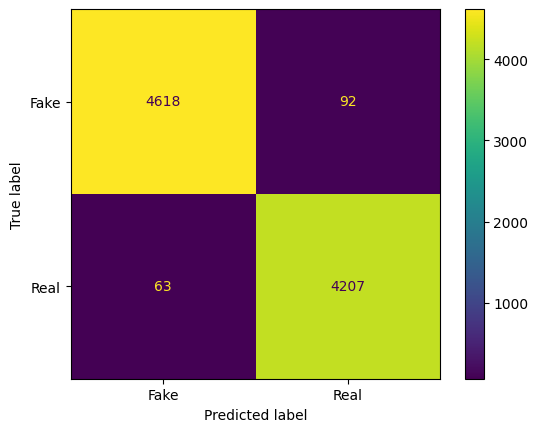

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

fake = pd.read_csv("Fake.csv")
real = pd.read_csv("True.csv")

#print("Fake News Shape:", fake.shape)
#print("Real News Shape:", real.shape)


fake["label"] = 0      # Fake
real["label"] = 1      # Real


df = pd.concat([fake, real], ignore_index=True)
#print("Combined Dataset Shape:", df.shape)

df = df.sample(frac=1, random_state=42)

df.dropna(inplace=True)

"""
print("\nMissing Values:")
print(df.isnull().sum())

plt.figure(figsize=(6,4))
df["label"].value_counts().plot(kind="bar")
plt.xticks([0,1], ["Fake","Real"])
plt.title("Number of Fake vs Real News Articles")
plt.show()
"""

X = df["text"]
y = df["label"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

"""
print("\nTraining Samples:", len(X_train))
print("Testing Samples:", len(X_test))
"""

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_df=0.7
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

"""
print("\nTF-IDF Matrix Shape:")
print(X_train_tfidf.shape)
"""

model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)
predictions = model.predict(X_test_tfidf)


accuracy = accuracy_score(y_test, predictions)
print("\nAccuracy:")
print(round(accuracy*100,2), "%")
print("\nClassification Report:")
print(classification_report(y_test, predictions))


cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fake","Real"]
)

disp.plot()
plt.show()

"""
sample_news = [
NASA announced a new mission to explore Mars and
study atmospheric changes over the next decade.

]

sample_vector = vectorizer.transform(sample_news)

prediction = model.predict(sample_vector)

if prediction[0] == 1:
    print("\nPrediction: REAL NEWS")
else:
    print("\nPrediction: FAKE NEWS")

"""

pickle.dump(
    model,
    open("model.pkl", "wb")
)

pickle.dump(
    vectorizer,
    open("vectorizer.pkl", "wb")
)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
